
# **A2.1 Regresión logística y validación cruzada**




La pobreza en México conlleva historias que van más allá de cifras. De acuerdo con el INEGI, en 2024 29.6% de la población nacional (38.5 millones de personas) se encontraba en situación de pobreza multidimensional, mientras que 7 millones vivían en pobreza extrema. Estas cifras reflejan desigualdades estructurales que atraviesan comunidades enteras y condicionan su futuro. [1]

La base de datos empleada en este estudio proviene de la integración de fuentes oficiales, con variables socioeconómicas y de bienestar recopiladas del portal estatal del [INEGI](https://www.inegi.org.mx/app/estatal/). [2]

Se trata de la misma base de datos utilizada en el trabajo previo **“La deserción escolar: análisis de sus determinantes socioeconómicos”**, correspondiente al periodo 2020–2022. Esto permite evaluar cómo factores estructurales recientes se relacionan con distintos niveles de abandono escolar en las 32 entidades federativas. Para la presente actividad se emplea la versión ya depurada del dataset, es decir, con el proceso de tratamiento y preparación de datos previamente realizado.

Teniendo como objetivo el adaptar el análisis de la pobreza a un escenario de clasificación binaria, evaluando rigurosamente la calidad del modelo de regresión logística mediante métricas como la exactitud, la sensibilidad y la especificidad. Asimismo, introduciendo el uso de la validación cruzada como herramienta metodológica para obtener estimaciones más sólidas y confiables.








### ***1. Importación de datos***

Para dar inicio al análisis técnico, es necesario cargar la base de datos correspondiente **`Desercion_depurado.csv`**, previamente recopilada del portal de datos.

Una vez que el archivo se encuentra en la carpeta de trabajo, se importará la librería `pandas`, la cual permite la manipulación y análisis de datos estructurados. Posteriormente, mediante el uso de la función `read_cvs()`, se realiza la lectura del archivo, almacenándose en un objeto `data`, el cual contendrá información de las 32 entidades federativas.

Igualmente, es necesario revisar el contenido del presente archivo. Mediante la función `print()` se aplicará la función `head()` en la variable `data`, desplegando por default las primeras cinco filas de datos.

In [ ]:
import pandas as pd
data =pd.read_csv('Desercion_depurado.csv')
print(data.head())

               Entidad  Pobreza  Desocupacion  Serv_salud  Red_apoyo  \
0       Aguascalientes     23.7      0.841393    0.828106  -0.358725   
1      Baja California     13.4     -0.666383    0.651229   1.044288   
2  Baja California Sur     13.3     -0.127892    1.543654   2.166698   
3             Campeche     45.1     -0.450987    0.152757   0.687157   
4             Coahuila     18.2      1.272187    1.350697   0.304518   

   Desercion  Sat_vida  Homicidios_log  Pm25_log  Analfabeta_log  \
0  -0.839486  0.662298       -1.264057 -0.239899       -1.419899   
1   0.190994  1.220023        1.502265  1.114353       -0.519580   
2   1.043805  0.662298       -0.662096 -2.202820       -1.886686   
3   0.581866 -1.010876       -0.566276  0.703408       -0.800024   
4   0.759535  1.777748       -1.388012 -0.477491       -0.836208   

   No_electricidad_log  Viv_habitadas_log  
0            -1.853407          -1.095109  
1             0.483087           0.422794  
2            -0.862994    

A continuación, se describen las variables incluidas en el análisis: [3]

*  `Entidad`  Nombre oficial de la entidad federativa.
*  `Pobreza`  Porcentaje de la población en situación de pobreza.
*  `Pm25` Concentración promedio de partículas PM2.5 (µg/m³).
*  `Homicidios` Tasa de desocupación (%).
*  `Desocupacion` Tasa de homicidios por cada 100 mil habitantes.
*  `Serv_salud` Porcentaje de población con acceso a servicios de salud.
*  `Red_apoyo` Porcentaje de población que reporta contar con redes de apoyo.
*  `Analfabeta_15` Número de personas mayores de 15 años que no saben leer ni escribir.
*  `No_electricidad` Número de viviendas sin acceso a electricidad.
*  `Viv_habitadas` Número total de viviendas habitadas en la entidad.
*  `Desercion`  Porcentaje de deserción escolar.
*  `Sat_vida` Nivel promedio de satisfacción con la vida.


Las variables expresadas en porcentaje representan proporciones relativas al total de viviendas de cada entidad federativa, lo cual permite comparabilidad territorial independientemente del tamaño poblacional.

**Vareiable de salida**

En el presente análisis, la variable de salida seleccionada es `Pobreza`, que representa el porcentaje de población en situación de pobreza multidimensional en cada entidad federativa.


De acuerdo con el INEGI, en 2024  el 29.6% de la población nacional se encontraba en situación de pobreza multidimensional, mientras que estados como Chiapas (66.0%), Guerrero (58.1%) y Oaxaca (51.6%) presentaron los niveles más altos. En contraste, entidades como Baja California (9.9%) o Nuevo León (10.6%) mostraron niveles bajos. Estos resultados permiten establecer que porcentajes superiores al 40% pueden considerarse “alta pobreza”, mientras que valores menores a ese umbral corresponden a “baja pobreza”. [3]


Del dataset previamente depurado se mantuvo la variable Pobreza en su escala original, con el propósito de aplicar el criterio oficial del 40% para la clasificación. Por lo tanto, para llevar a cabo el modelo de regresión logística, se binarizó la variable Pobreza de la siguiente manera:


* 1 = Alta pobreza (entidades con valores ≥ 40%)
* 0 = Baja pobreza (entidades con valores < 40%)

Para ello se creará una nueva variable binaria llamada `Pobreza_binaria`, a partir de la original `Pobreza`. Donde, se muestran las primeras filas `Entidad`, `Pobreza` con `.head()` y la nueva variable binarizada, para verificar que la transformación se realizó correctamente.






In [ ]:
import numpy as np

# Binarizar la variable 'Pobreza'
data['Pobreza_binaria'] = np.where(data['Pobreza'] >= 40, 1, 0)

# Mostrar las primeras filas con la nueva variable binarizada
print(data[['Entidad', 'Pobreza', 'Pobreza_binaria']].head())

               Entidad  Pobreza  Pobreza_binaria
0       Aguascalientes     23.7                0
1      Baja California     13.4                0
2  Baja California Sur     13.3                0
3             Campeche     45.1                1
4             Coahuila     18.2                0


La nueva variable de salida correponderá a **pobreza binaria**, la cual clasifica a las observaciones en dos categorías: presencia o ausencia de pobreza; permitiendo así adaptar el problema a un escenario de clasificación.

En cuanto al equilibrio de clases, es de importancia el análisis de la proporción de observaciondes por categoría. Puesto que, si ambas clases (pobreza y no pobreza) se encuentran relativamente balanceadas, el modelo puede aprender de forma confiable su desempeño.

Sin embargo, si existe un desbalance marcado, tal como muchas observaciones con pobreza y pocas sin pobreza o viceversa; el modelo podría sesgarse hacia la clase mayoritaria y la exactitud dejaría de ser una métrica suficiente para evaluar la calidad del modelo.


### ***2. Separación en entrenamiento y prueba***

De esta manera, se realizará la separación de los datos en dos subconjuntos: 80% para entrenamiento y 20% en prueba.

Donde, con el fin de mantener la representatividad de la variable de salida, se  imprimirán en consola las proporciones de cada clase en los tres grupos (datos originales, entrenamiento y prueba), lo que permitirá verificar que el balance de clases se mantiene constante durante la división.

Para ello, se empleará la función  `train_test_split` del módulo `sklearn.model_selection`, asegurando que las variables de prueba no se usaran durante el entrenamiento, evitando así la fuga de información.

In [ ]:
from sklearn.model_selection import train_test_split


X = data.drop(columns=['Pobreza_binaria'])
y = data['Pobreza_binaria']                 # Variable de salida

# Separar en entrenamiento y prueba con 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Proporciones de clases
print("Proporción original:")
print(y.value_counts(normalize=True))

print("\nProporción entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nProporción prueba:")
print(y_test.value_counts(normalize=True))

Proporción original:
Pobreza_binaria
0    0.59375
1    0.40625
Name: proportion, dtype: float64

Proporción entrenamiento:
Pobreza_binaria
0    0.6
1    0.4
Name: proportion, dtype: float64

Proporción prueba:
Pobreza_binaria
0    0.571429
1    0.428571
Name: proportion, dtype: float64


Mostrándose que la división de los datos en entrenamiento y prueba conservó el balance de clases.

Donde, en los datos originales había cerca de 59% de clase 0 (baja pobreza) y 41% de clase 1 (alta pobreza); en el conjunto de entrenamiento se mantuvo prácticamente igual (60% y 40%), y en el de prueba también se respetó la proporción (57% y 43%).

 Asegurandose que ambos conjuntos sean representativos de la distribución original permitiendo que métricas como la sensibilidad y la especificidad reflejen los resultados de manera más confiable.


### ***2.1. Selección de características***



En esta sección, se llevará a cabo un proceso de selección de características que nos permitirá identificar las variables con mayor poder explicativo para análizar el fenómeno de la pobreza.

Para ello se utilizará la técnica de regulización de Lasso (Least Absolute Shrinkage and Selection Operator), la cual permite reducir coeficientes hacia cero y en consecuencia, eliminar aquellas variables que no aportan relevancia predictiva al modelo. [4]

Resultando útil para identificar contextos donde existe multicolinealidad o riesgo de sobreajuste, mejorando así la interpretabilidad del modelo al conservar los predictores más significativos. [4]

Usando la clase `Lasso` de scikit-lear para seleccionar variables, donde, definiendo las variables de entrenamiento; se crea el modelo con `alpha=0.5` para aplicar la penalización. Descartando las variables que quedan en cero y manteniendo los distintos a cero.

In [ ]:
from sklearn.linear_model import Lasso
import pandas as pd
import numpy as np

alpha_ajustado = 0.05

modelo_lasso = Lasso(alpha=alpha_ajustado, random_state=42)

X_train_numerical = X_train.drop(columns=['Entidad','Pobreza'])

modelo_lasso.fit(X_train_numerical, y_train)

coeficientes = pd.Series(modelo_lasso.coef_, index=X_train_numerical.columns).sort_values(ascending=False)

print(f"--- Coeficientes Lasso con Alpha = {alpha_ajustado} ---")
print(coeficientes)

# Cantidad de variables que quedaron con peso
print(f"\nVariables con impacto real: {(modelo_lasso.coef_ != 0).sum()} de {len(X_train_numerical.columns)}")

--- Coeficientes Lasso con Alpha = 0.05 ---
Desocupacion           0.000000
Desercion              0.000000
No_electricidad_log   -0.000000
Homicidios_log         0.000000
Analfabeta_log        -0.000000
Pm25_log               0.000000
Red_apoyo             -0.009357
Viv_habitadas_log     -0.059664
Sat_vida              -0.096520
Serv_salud            -0.282802
dtype: float64

Variables con impacto real: 4 de 10


Tras analizar las variables, es posible determinar que se ha reducido el ruido del dataset original de 10 variables a solo 4 predictores clave.

Las cuatro variables seleccionadas presentan coeficientes negativos:
* Serv_salud (-0.2828): Es el predictor de mayor peso, indicando el que acceso a servicios de salud es el factor que más contribuye a reducir la probabilidad de que alguna entidad sea clasificada en *Pobreza alta*.
* Sat_vida (-0.0965): Indica que la satisfacción con la vida influye significativamente con mejores condiciones  económicas.
* Viv_habitadas_log (-0.0596): Indica que mejor situación de vivencia se relaciona con menor riesgo de pobreza.
* Red_apoyo (-0.0093): Indica que, a pesar de tener un peso menor, aporta una pespectiva social que el resto de las variables no aportan.

Factores como *Desocupacion, Desercion, Analfabeta_log y Homicidios_log* fueron eliminados debido a la redundancia de su información. Por lo que su relacion estadística con la variable dependiente *Pobreza_binaria* no es lo suficientemente fuerte bajo la penalización de $\alpha$ = 0.05.

Una vez seleccionadas las variables ocn mayor relevancia mediante la técnica Lasso, se procederá a realizar un filtrado y validación mediante un mapa de calor de correlaciones de Pearson. Con el objetivvo de identificar relaciones lineales entre las variables independientes, permitiendo visualizar de manera clara, aquellas variables altamente correlacionadas que pudieran generar problemas de multicolinealidad en el modelo.

Donde, se seleccionarán las variables numéricas con la función `data.[nums_vars].corr()` representándose en el mapa de calor mediante `sns.heatmap`. Agregando detalles al gráfico con `plt.figure` y `plt.title`, para finalmente mostrarse con `plt.show()`.

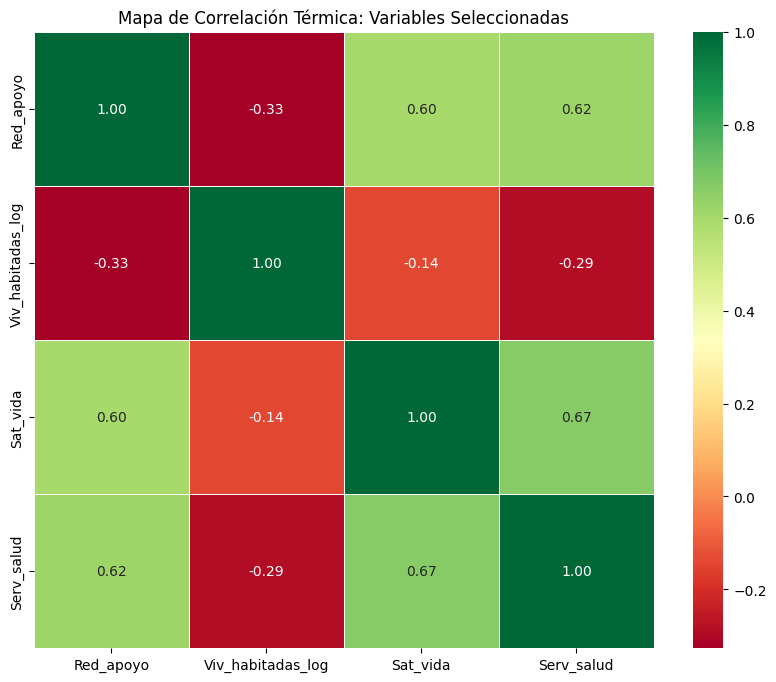

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Creamos un subset con las variables especificadas por el usuario
variables_analisis = ["Red_apoyo", "Viv_habitadas_log", "Sat_vida", "Serv_salud"]
df_correlacion = data[variables_analisis].corr()

# 2. Graficar el Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(df_correlacion,
            annot=True,       # Muestra los números de correlación
            cmap='RdYlGn',    # Escala de colores: Rojo (negativo), Amarillo (neutro), Verde (positivo)
            fmt=".2f",        # Dos decimales
            linewidths=0.5)

plt.title('Mapa de Correlación Térmica: Variables Seleccionadas')
plt.show()

El mapa de calor antes observado confirma que las cuatro variables tienen relaciones entre sí, pero mantienen su independencia para no generar problemas de multicolinealidad:

Es posible observar una correlación positiva moderada entre *Sat_vida, Red_apoyo y Serv_salud* (valores entre 0.60 y 0.67) indicando que en entidades donde mejora el acceso a salud, mejora la satisfacción de vida y apoyo social.Donde al no superar valores de 0.80 es posible deducir que aportan información distinta.

 Asimismo, la variable *Viv_habitadas_log* muestra correlaciones bajas o negativas con las demás.Indicando que dicha variable mide algo que el bloque social no captura.


### ***3. Validación cruzada con regresión logística***



Con base en el análisis de selección previamente realizado y depurado, se utilizarán como variables explicativas  del modelo de regresión logística: `Red_apoyo, Viv_habitadas_log, Sat_vida y Serv_salud`. Estas características se emplearán unicamente en el conjunto de entrenamiento para estimar el desempeño del modelo.

Consistiendo en aplicar validación cruzada, donde se dividirá el conjunto de entrenamiento en pliegues, permitiendo evaluar nuestro modelo en cada uno de ellos. [5]

Así, será posible reportar métricas de calidad relevantes, tal como la exactitud, precisión, sensibilidad y especificidad, que permitirán evaluar la capacidad del modelo para identificar los casos de probreza y no pobreza.

Para ello, se utilizará la función `cross_validate` del módulo `sklearn.model_selection` para aplicar validación cruzada sobre el conjunto de entrenamiento. Empleando métricas de `sklearn.metrics` como `accuracy_score`, `recall_score`, `precision_score`, que permiten calcular los indicadores de calidad relevantes.


In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, recall_score, precision_score


X = data[["Red_apoyo", "Viv_habitadas_log", "Sat_vida",'Serv_salud']]
y = data["Pobreza_binaria"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

log_reg = LogisticRegression(max_iter=1000, penalty="l2")


scoring = {
    "accuracy": make_scorer(accuracy_score),
    "sensitivity": make_scorer(recall_score, pos_label=1),
    "specificity": make_scorer(recall_score, pos_label=0),
    "precision": make_scorer(precision_score, pos_label=1)
}


cv_results = cross_validate(log_reg, X_train, y_train, cv=5, scoring=scoring)


print("Métricas Promedio en Validación Cruzada")
print("Exactitud promedio:", cv_results["test_accuracy"].mean())
print("Sensibilidad promedio:", cv_results["test_sensitivity"].mean())
print("Especificidad promedio:", cv_results["test_specificity"].mean())
print("Precisión promedio:", cv_results["test_precision"].mean())

Métricas Promedio en Validación Cruzada
Exactitud promedio: 0.96
Sensibilidad promedio: 0.9
Especificidad promedio: 1.0
Precisión promedio: 1.0


Por su parte, tras el análisis mediante validación cruzada podemos observar un desempeño alto del modelo.

* Exactitud (0.96): Indica que el 96% de las observaciones totales fueron clasificadas correctamente, lo que demuestra un desempeño sobresaliente del modelo.

* Sensibilidad (0.90): Indica que el modelo identificó el 90% de los casos de alta pobreza; esto es crucial, ya que reduce significativamente los falsos negativos.

* Especificidad (1.0): Indica que el modelo logró un 100% de acierto al clasificar los casos de baja pobreza, siendo perfecto al detectar los casos de "No pobreza".

* Precisión (1.0): Indica que el 100% de las predicciones marcadas como pobreza corresponden a casos reales.

De manera que, esta metodología es un estimador más robusto del desempeño esperado que una sola partición, ya que al promediar los resultados de 5 pliegues diferentes, nos aseguramos de que el éxito del modelo no se deba a una sola división de los datos, sino a una verdadera capacidad de las variables.

Aunque los resultados son excelentes (96% de exactitud), es necesario tomarlos con cautela. Una precisión tan alta podría indicar que el modelo se  encuentra sobreajustado o que la muestra es muy predecible.

Por ello, para confirmar que el modelo realmente funciona, realizaremos más adelante una evaluación final con el conjunto de prueba, analizando la matriz de confusión y la curva ROC para verificar su capacidad real de generalización.

### ***Entrenamiento del modelo y evaluación del conjunto de prueba***

Para esta sección se entrenará un modelo de regresión logística utilizando la totalidad del conjunto de entrenamiento con las variables seleccionadas.

Donde, para evaluar el desempeño se utilizará el conjunto de prueba. Presentando en una matriz de confusión, de manera más clara como fueron clasificadas las observaciones en las categorías de pobreza y no probreza, identificando aciertos y errores del modelo.

Por lo cual, se empleo la función `train_test_split` para que el modelo se ajuste unicamente al conjunto de entrenamiento, entrenandse con `LogisticRegression` y generando predicciones sobre el conjunto de prueba. Donde, con la función `confusion_matrix` se compararon las etiquetas reales con las predichas, mientras que `ConfusionMatrixDisplay` mostrará la capacidad de distinción del modelo.



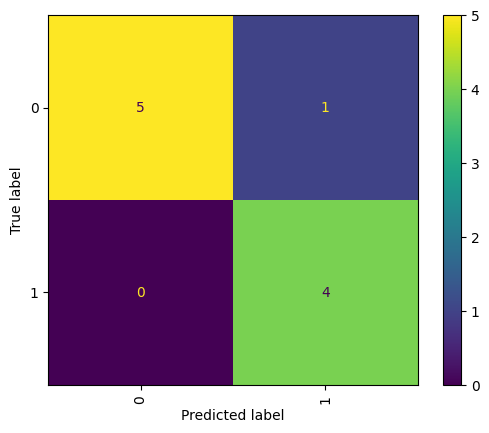

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split


X = data[["Red_apoyo", "Viv_habitadas_log", "Sat_vida",'Serv_salud']]
y = data["Pobreza_binaria"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)


log_reg = LogisticRegression(max_iter=1000, penalty="l2")
log_reg.fit(X_train, y_train)

# Predicciones sobre el conjunto de prueba
y_pred_test = log_reg.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=log_reg.classes_)
disp.plot(xticks_rotation="vertical")

Al ver los resultados, podemos observar que el modelo tubo un desempeño sobresaliente:
* Se clasificaron correctamente 5 casos de **no pobreza**.
* Se clasificaron correctamente 4 casos de **pobreza**.
* Hubo un caso donde una entidad perteneciente a **no pobreza** fue clasificada erroneamente en **pobreza**
* El modelo sobresalió al no omitir ningun caso de **pobreza**.

Cabe destacar que, a pesar de que el modelo demostró buen desempeño, el conjunto de prueba es reducido a 10 observaciones en total, por lo que estas métriocas deben analizarse con detalle. No obstante, la coincidencia entre estos resultados y la validación cruzada (Exactitud: 87.62%) sugiere que el modelo es robusto y tiene una capacidad de generalización confiable.

A continuación continuaremos con las métricas de calidad bajo distintos umbrales de decisión, lo que permitirá observar cómo varía el desempeño del modelo al modificar el punto de corte de probabilidad.

Este análisis es  relevante en nuestro caso, ya que el conjunto de prueba cuenta con pocas observaciones y, por lo tanto, los resultados pueden mostrar métricas perfectas que no necesariamente reflejan el comportamiento en muestras más grandes. Al comparar estos valores con los obtenidos mediante validación cruzada, se puede verificar la confiabilidad de la metodología.

Para ello se utilizará la función `predict_proba` para obtener las probabilidades estimadas de cada observación. Recalculando las métricas como `accuracy_score`, `recall_score`, `precision_score` para verificar la confiabilidad de la metodología utilizada.




In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

# Probabilidades predichas
y_proba_test = log_reg.predict_proba(X_test)[:, 1]


def evaluar_umbral(umbral):
    y_pred_umbral = (y_proba_test >= umbral).astype(int)
    accuracy = accuracy_score(y_test, y_pred_umbral)
    sensitivity = recall_score(y_test, y_pred_umbral, pos_label=1)   # clase 1 = alta pobreza
    specificity = recall_score(y_test, y_pred_umbral, pos_label=0)   # clase 0 = baja pobreza
    precision = precision_score(y_test, y_pred_umbral, pos_label=1)
    print(f"Umbral: {umbral}")
    print(f"  Exactitud: {accuracy:.3f}")
    print(f"  Sensibilidad: {sensitivity:.3f}")
    print(f"  Especificidad: {specificity:.3f}")
    print(f"  Precisión: {precision:.3f}")
    print("-"*40)

# Evaluar con distintos umbrales
for umbral in [0.1, 0.5, 0.9]:
    evaluar_umbral(umbral)

Umbral: 0.1
  Exactitud: 0.500
  Sensibilidad: 1.000
  Especificidad: 0.167
  Precisión: 0.444
----------------------------------------
Umbral: 0.5
  Exactitud: 0.900
  Sensibilidad: 1.000
  Especificidad: 0.833
  Precisión: 0.800
----------------------------------------
Umbral: 0.9
  Exactitud: 0.700
  Sensibilidad: 0.250
  Especificidad: 1.000
  Precisión: 1.000
----------------------------------------


Se seleccionaron los umbrales***0.1, 0.5 y 0.9*** para verificar como varían las métricas de calidad.

En teoría, un umbral bajo (0.1) debería mostrar alta sensibilidad (detecta casi todos los positivos), pero baja especificidad (muchos falsos positivos. Mientras que un umbral alto (0.9) debería hacer lo contrario, - dar alta especificidad (pocos falsos positivos), pero baja sensibilidad (pierde positivos); siendo el umbral de 0.5 el balance entre sensibilidad y especificidad.

* El umbral de 0.1 cuenta con una sensibilidad perfecta (1.0), no dejando afuera ningún caso de pobreza. Sin embargo, cuenta con una especificidad muy baja (0.167), clasificando a casi todos los estados como pobres, incluso cuando no lo son (falsos positivos).

* El umbral de 0.5 cuenta con una exactitud sobresaliente (0.9) indicando que el modelo acierta 9 de cada 10 casos. Mantiene una sensibilidad perfecta (1.0) por lo cual detecta la pobreza, subiendo la especificidad a un 83%.

* El umbral de 0.9 es más exigente, clasificando en "Pobreza" a entidades con probabilidades mayores iguales a 90%. Con una presición perfecta (1.0) da la certeza que cuando menciona que una entidad se encuentra en pobreza, está 100% seguro de que lo está. Sin embargo, su sensibilidad baja hasta 25%, indicando que se detecta un pequeño porcentaje de pobreza real, ignorando alrededor del 75% del resto.

Determinando que, el valor de 0.5 es el más adecuado para este modelo, logrando una exactitud del 90%. Mientras que un umbral bajo (0.1) satura el modelo con falsos positivos, un umbral alto (0.9) es demasiado restrictivo omitiendo al 75% de la población. Garantizando así un equilibrio con la detección acertada.


### ***5. Curva ROC y AUC***

En esta sección se llevará a cabo la curva ROC (Receiver Operating Characteristic) construyéndose a partir de las probabilidades estimadas por el modelo; mostrando un relación entre la sensibilidad (tasa de verdaderos positivos) y el 1 - especificidad (tasa de falsos positivos) para disntos umbrales de decisión.

Donde, cada punto perteneciente a la curva muestra la relación entre  detectar correctamente los casos positivos y evitar clasificar erróneamente los negativos.

Asimismo, el área bajo la curva (AUC) permitirá resumir en un solo valor la capacidad discriminativa del modelo: un AUC cercano a 1 indica que el modelo distingue muy bien entre las clases, mientras que un AUC cercano a 0.5 refleja un desempeño similar al azar.

Utilizando la función `roc_curve`, se calculará la relación entre sensibilidad y falsos positivos. Mediante `matplotlib`, se graficará la línea de desempeño (naranja) frente al azar (azul punteada), lo que permitirá validar visualmente la capacidad del modelo para distinguir entre pobreza y no pobreza. Obteniendo el valor AUC como indicador global de precisión.





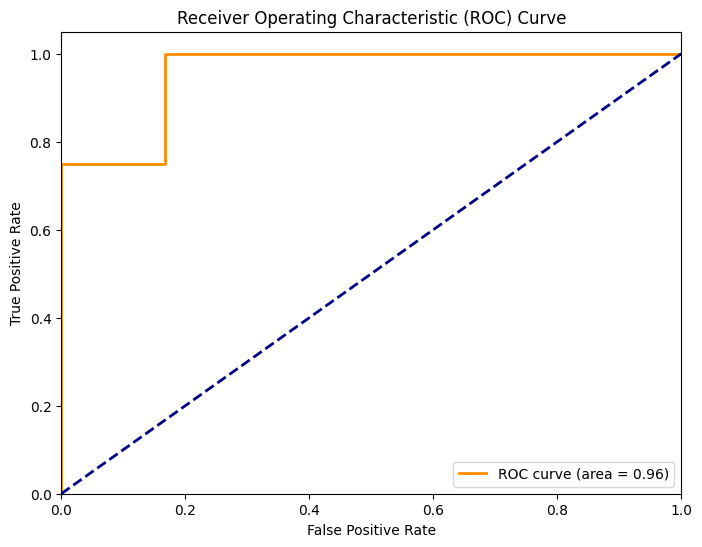

Area Under the Curve (AUC): 0.958


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_test)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

print(f"Area Under the Curve (AUC): {roc_auc:.3f}")

Es posible observar que el modelo final tiene un desempeño sobresaliente con un AUC de 0.958, demostrando alta capacidad discriminativa. Con una capacidad casi perfecta para distinguir entre una entidad pobre y una no pobre, validando la confiabilidad del modelo.

Donde, la curva ROC indica que existe un umbral donde es posible obtener casi un 80% de sensibilidad con 0% de falsos positivos. Por otra parte, siendo posible llegar a un 100% de sensibilidad aceptando alrededor de 18% de falsos positivos, confirmando lo que se observó en la matriz de confusión. Indicando que es un modelo capaz de tomar desiciones en diagnósticos de pobreza.

### ***6. Interpretación del modelo y conclusiones***

En esta sección, se procederá a la extracción e interpretación de los coeficientes del modelo de regresión logísica final. Buscando así, cuantificar el impacto individual de cada variable predictora sobre la probabilidad de pertenecer a la clase de "Pobreza alta".

Utilizando el atributo `.intercept_` y `.coef_` para extraer los pesos de las variables independientes.


In [ ]:
import pandas as pd

# 1. Extraer intercepto y coeficientes
intercepto = log_reg.intercept_[0]
coeficientes = log_reg.coef_[0]

# 2. Crear tabla con las variables seleccionadas por Lasso
variables = ['Serv_salud', 'Sat_vida', 'Red_apoyo', 'Viv_habitadas_log']
df_resultados = pd.DataFrame({
    'Variable': variables,
    'Coeficiente': coeficientes
})

# 3. Mostrar resultados ordenados por magnitud (importancia)
print(f"Intercepto: {intercepto:.4f}")
print("-" * 30)
print(df_resultados.sort_values(by='Coeficiente'))

Intercepto: -0.5701
------------------------------
            Variable  Coeficiente
3  Viv_habitadas_log    -1.509430
2          Red_apoyo    -0.833924
0         Serv_salud    -0.626788
1           Sat_vida    -0.398138


Tras ajustar los resultados, se obtuvo un intercepto de -0.5701, para posterirmente analizar los coeficientes que determinan cómo cada variable impacta en que una entidad sea clasificada en pobreza.

Es posible observar que todas las variables cuentan con coeficientes negativos, indicando una relación inversa a la pobreza; es decir, al aumentar estas variables, la probabilidad de ser una entidad en pobreza es menor. Donde, *Viv_habitadas_log (-1.5094)* es la variable con más pedo, indicando que el aumento en calidad y disponibilidad de vivienda tiene mayor impacto en un menor índice de pobreza. Además, variables como *Red_apoyo (-0.8339), Sat_vida (-0.3981) y Serv_salud (-0.6268)* tienen una influencia moderada, indicando que el bloque social y acceso a servicios son esenciales para la estabilidad.

Permitiendonos conluir y reflexionar tras analizar el modelo que, la vivienda es una carencia determinante, mientras que variables relacionadas a salud y redes de apoyo son mecanismos importantes de protección social. Donde, con un modelo de clasificación de alta precisión (AUC = 0.96), se presenta a la probreza como un fénomeno multidimensional que depende de infraestractura básica y servicios sociales estables. Asimismo, la dirección negativa de los coeficientes y su magnitud relativa indican que el fortalecimiento de estos bloques es estadísticamente coherente y fundamental para reducir la probabilidad de vulnerabilidad que conlleva esta problemática.

### ***Referencias***


1. admin, “En México, más de 46 millones de personas viven en situación de pobreza,” Gaceta UNAM, Sep. 09, 2024. https://www.gaceta.unam.mx/en-mexico-mas-de-46-millones-de-personas-viven-en-situacion-de-pobreza/
‌
2. “Banco de Indicadores - Indicadores por entidad federativa,” www.inegi.org.mx. https://www.inegi.org.mx/app/estatal/

3. “POBREZA MULTIDIMENSIONAL,” INEGI. https://www.inegi.org.mx/contenidos/saladeprensa/boletines/2025/pm/pm2025_08.pdf
‌
4. IBM, “Regresión Lasso,” Ibm.com, Jan. 16, 2024. https://www.ibm.com/mx-es/think/topics/lasso-regression

5. scikit learn, “3.1. Cross-validation: Evaluating Estimator Performance — scikit-learn 0.21.3 Documentation,” Scikit-learn.org, 2009. https://scikit-learn.org/stable/modules/cross_validation.html
‌
‌